In [1]:
!pip install gymnasium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 46.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [gymnasium]/2 [gymnasium]


In [2]:
!pip install sb3-contrib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [sb3-contrib] [sb3-contrib]


In [3]:
import sys
sys.path.append("/project_ghent/chronocooked")

In [4]:
import matplotlib.pyplot as plt
from singleagent.rl_environments.time_production_basic import TimeProductionBasic
from sb3_contrib import RecurrentPPO
from stable_baselines3 import PPO
import numpy as np
import pandas as pd

In [5]:
import os
# import seaborn as sns

In [6]:
# from model_wrappers.sb3CnnLstmMlpWrapper import sb3CnnLstmMlpWrapper
from singleagent.eval.utils import get_first_oven_check, event_info_history
import torch as th
import random
# from scipy import stats
from tensorboard.backend.event_processing import event_accumulator

In [4]:
# from utils import get_first_oven_check, event_info_history
# from analysis.utils import is_adjacent_oven

In [7]:
import matplotlib.cm as cm
import matplotlib
# import seaborn as sns
# from scipy.stats import gaussian_kde

In [8]:
from matplotlib.lines import Line2D

In [9]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import ttest_ind, shapiro, levene, ttest_1samp, f_oneway, ttest_rel
# from statsmodels.stats.diagnostic import het_breuschpagan

In [10]:
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

In [11]:
import matplotlib as mpl

mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False

In [9]:
for k in [
    "font.size",
    "axes.titlesize",
    "axes.labelsize",
    "xtick.labelsize",
    "ytick.labelsize",
    "legend.fontsize",
]:
    print(k, matplotlib.rcParams[k])

font.size 12.0
axes.titlesize large
axes.labelsize 13.0
xtick.labelsize 11.0
ytick.labelsize 11.0
legend.fontsize medium


In [12]:
# map seed to each starting point
env = TimeProductionBasic(oven_duration=9)
seeds = {(int(ax),int(ay)): -1 for ax, ay in zip(np.where(env.reset(seed=0)[0][:,:,0] ==0)[0],np.where(env.reset(seed=0)[0][:,:,0] ==0)[1])}
for s in range(1,30,1):
    
    ax, ay = np.where(env.reset(seed=s)[0][:,:,1] ==1)
    if seeds[int(ax[0]),int(ay[0])] == -1:
        seeds[int(ax[0]),int(ay[0])] = s
seeds

{(0, 0): 2,
 (1, 0): 14,
 (1, 1): 1,
 (1, 2): 3,
 (2, 1): 13,
 (2, 2): 7,
 (3, 0): 25,
 (3, 1): 9,
 (3, 2): 17,
 (4, 0): 5,
 (4, 1): 19,
 (4, 2): 20}

In [13]:
def plot_traj(obs_list, action_list, value_list = None, event_list=None):
    plt.figure(figsize=(15,15))
    obs_concat = np.hstack(np.array(obs_list))
    action_concat = np.hstack(action_list)
    if event_list is not None:
        event_concat = np.hstack(event_list)
        plt.imshow(obs_concat, cmap = 'magma', vmin=0, vmax=5, interpolation='nearest')
        x_ticks = range(0, obs_concat.shape[1], 3)
        # labels = [f"Action:{a}, Event:{e}" for a, e in zip(action_concat[x_ticks], event_concat[x_ticks])]
        x = plt.xticks(x_ticks, [f"{str(l[1])} \nAction: {int(l[0])}" for l in zip(action_concat, event_concat, range(len(event_concat)))], rotation =90, ha='left', fontsize=10)
    elif value_list is not None:
        plt.imshow(obs_concat, cmap = 'magma', vmin=0, vmax=5, interpolation='nearest')
        value_concat = np.hstack(value_list)
        x_ticks = range(0, obs_concat.shape[1], 3)
        x = plt.xticks(x_ticks, [f"{int(l[0])} , {str(l[1])}, {str(l[2])} " for l in zip(action_concat, range(len(action_concat)), value_concat)], rotation =90, ha='right', fontsize=10)
    else:
        plt.imshow(obs_concat, cmap = 'magma', vmin=0, vmax=5, interpolation='nearest')
        x_ticks = range(0, obs_concat.shape[1], 3)
        x = plt.xticks(x_ticks, [f"{int(l[0])} , {str(l[1])}" for l in zip(action_concat, range(len(action_concat)))], rotation =90, ha='right', fontsize=10)



In [14]:
def is_adjacent_ovenon(arr, agent=1, oven_on=6):
    pos_a = np.argwhere(arr == agent)
    pos_b = np.argwhere(arr == oven_on)

    if len(pos_a) == 0 or len(pos_b) == 0:
        return False

    r1, c1 = pos_a[0]
    r2, c2 = pos_b[0]

    return abs(r1 - r2) + abs(c1 - c2) == 1

In [ ]:
# convergence 

In [ ]:
# FOC - lstm 

In [15]:
 
# change code to run model instead of calling a function 
def get_foc_data(lstm_size=None, ctrnn=False):
    if ctrnn:
        label = f"CTRNN{lstm_size}"
    elif lstm_size is None:
        label = "CNN"
    else:
        label = f"LSTM{lstm_size}"

    target_durations = [4,6,9,12,18,24]
    rows=[]
    ent_coeff = 0
    timestep = 200
    g = 0.99
    for target_duration in target_durations:

        env = TimeProductionBasic(oven_duration=target_duration, max_timesteps=timestep)
        
        models_folder = "/project_ghent/chronocooked/singleagent/train/FI_modelsv1"
        for log in [1,2,3,4]:
            
            if ctrnn:
                model_suffix = f"v1_FI{target_duration}_cnnout64_ts{timestep}_entcoef{ent_coeff}_nepoch20_ctrnn{lstm_size}_mlp64_gamma{g}_logs{log}/"
            elif lstm_size == None:
                model_suffix = f"v1_FI{target_duration}_cnnout64_ts{timestep}_entcoef{ent_coeff}_nepoch20_mlp64_gamma{g}_logs{log}/"
            else:
                model_suffix = f"v1_FI{target_duration}_cnnout64_ts{timestep}_entcoef{ent_coeff}_nepoch20_sharedlstm{lstm_size}_mlp64_gamma{g}_logs{log}/"


            model_path = f"{models_folder}/{model_suffix}"
            try:
                dir_check = os.listdir(model_path)
            except:
                print("could not list dir",model_path)
                continue
    
            
            ts_values = sorted([int(tf.split("_")[2]) for tf in os.listdir(model_path) if "zip" in tf], reverse=2)[:1]

            for ts in ts_values:
                ts_i = str(ts) + "_" + str(log)
                try:
                    if lstm_size == None:
                        model = PPO.load(f"{model_path}/rl_model_{ts}_steps", env=env)
                    else:
                        
                        model = RecurrentPPO.load(f"{model_path}/rl_model_{ts}_steps", env=env)
                except:

                    print("could not load model",f"{model_path}/rl_model_{ts}_steps")
                    continue
        

                
                for s_i, s in enumerate(seeds.values()): 
                    # if s_i != 10:
                    #     continue
                    first_obs_raw,_ = env.reset(seed=s)
                    first_obs = np.array(first_obs_raw, copy=True) 
                                        
            
                    event_info = event_info_history.get_event_info_history(model, env, first_obs, timesteps=200)
                    actions = [event_info[i]["action"] for i in event_info.keys() ]
                    oven_timers = [event_info[i]["oven_timer"] for i in event_info.keys() ]
                    rewards = [event_info[i]["reward"] for i in event_info.keys() ]
                    soups_delivered = [event_info[i]["num_soups_delivered"] for i in event_info.keys() ]
                    adj_oven_concat = [is_adjacent_ovenon(x["observation"]) for x in event_info.values()]
                    # print(actions)
                    timing_actions = [a for a, t in zip(actions, oven_timers) if t != -1]
            
                    # first_oven_checks, _ = get_first_oven_check.get_oven_checks(actions, oven_timers, target_duration)
                    first_oven_checks = get_first_oven_check.get_oven_checks_modified(actions, oven_timers, adj_oven_concat, target_duration)
                    # print(first_oven_checks)
                    if len(first_oven_checks) == 0:
                        print("model did not converge", len(actions), f"{model_path}/rl_model_{ts}_steps")                        
                        # raise ValueError(model_suffix, s, obs_print)
                        break
                    # foc_seeds[s_i] = first_oven_checks
                    rows.append({"TD":target_duration, "p_id":ts_i, "seed":s_i,"foc":first_oven_checks[0], "model":label, "timing_actions":timing_actions})
    foc_data_df = pd.DataFrame(rows)
    return foc_data_df


In [16]:
foc_data_df_lstm8 = get_foc_data(lstm_size=8, ctrnn=False)
foc_data_df_lstm125 = get_foc_data(lstm_size=125, ctrnn=False)
foc_data_df_lstm256 = get_foc_data(lstm_size=256, ctrnn=False)
foc_data_df_cnn = get_foc_data(lstm_size=None, ctrnn=False)

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
model did not converge 200 /project_ghent/chronocooked/singleagent/train/FI_modelsv1/v1_FI4_cnnout64_ts200_entcoef0_nepoch20_sharedlstm8_mlp64_gamma0.99_logs2//rl_model_900000_steps
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
model did not converge 200 /project_ghent/chronocooked/singleagent/train/FI_modelsv1/v1_FI6_cnnout64_ts200_entcoef0_nepoch20_sharedlstm8_mlp64_gamma0.99_logs3//rl_model_900000_steps
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
model did not conver

In [16]:
foc_data_df_lstm125.groupby(["TD","p_id"])["foc"].describe()

count       mean       std   min    25%   50%    75%   max
TD p_id                                                                
4  900000_1   12.0   4.166667  0.834847   3.0   3.75   4.0   5.00   5.0
   900000_2   12.0   3.833333  0.389249   3.0   4.00   4.0   4.00   4.0
   900000_3   12.0   4.000000  0.000000   4.0   4.00   4.0   4.00   4.0
   900000_4   12.0   3.916667  0.514929   3.0   4.00   4.0   4.00   5.0
6  900000_1   12.0   5.416667  1.781640   0.0   5.75   6.0   6.00   7.0
   900000_2   12.0   5.750000  0.753778   4.0   5.75   6.0   6.00   7.0
   900000_3   12.0   5.750000  1.422226   2.0   5.75   6.0   6.00   8.0
   900000_4   12.0   5.583333  0.792961   4.0   5.00   6.0   6.00   7.0
9  900000_1   12.0   8.750000  1.356801   6.0   8.00   8.5  10.00  11.0
   900000_2   12.0   9.333333  0.778499   8.0   9.00   9.0  10.00  11.0
   900000_3   12.0   8.916667  0.996205   7.0   8.00   9.0  10.00  10.0
   900000_4   12.0   9.083333  0.514929   8.0   9.00   9.0   9.00  10.0
12 900000_1   12.0  10.000000  3.490246   0.0  10.00  11.0  12.00  13.0
   900000_2   12.0  11.500000  1.167748  10.0  11.00  11.0  12.00  14.0
   900000_3   12.0  12.583333  1.378954  11.0  12.00  12.0  13.00  16.0
   900000_4   12.0  11.750000  0.452267  11.0  11.75  12.0  12.00  12.0
18 900000_1   12.0  17.833333  2.249579  15.0  16.00  17.5  19.25  22.0
   900000_2   12.0  18.583333  1.443376  16.0  18.00  18.0  20.00  21.0
   900000_3   12.0  17.250000  3.493500   7.0  16.75  18.0  19.00  20.0
   900000_4   12.0  19.083333  1.928652  17.0  17.75  19.0  20.00  23.0
24 900000_1   12.0  22.250000  1.712255  19.0  21.50  23.0  23.25  24.0
   900000_2   12.0  23.166667  1.527525  21.0  22.00  23.0  24.00  26.0
   900000_3   12.0  22.416667  4.581749  12.0  20.75  23.5  26.00  28.0
   900000_4   12.0  23.166667  2.167249  20.0  21.00  23.0  24.25  27.0

In [19]:
foc_data_df_lstm8.groupby(["TD","p_id"])["foc"].describe()

count       mean       std   min    25%   50%    75%   max
TD p_id                                                                
4  900000_1   12.0   4.000000  0.000000   4.0   4.00   4.0   4.00   4.0
   900000_3   12.0   2.416667  0.792961   2.0   2.00   2.0   2.25   4.0
   900000_4   12.0   3.750000  0.452267   3.0   3.75   4.0   4.00   4.0
6  900000_1   12.0   2.833333  2.249579   0.0   0.00   3.0   5.00   5.0
   900000_2   12.0   5.000000  0.000000   5.0   5.00   5.0   5.00   5.0
9  900000_2   11.0   3.181818  2.400757   0.0   1.00   5.0   5.00   6.0
   900000_4    6.0  10.000000  0.000000  10.0  10.00  10.0  10.00  10.0
12 900000_1    6.0  16.166667  0.408248  16.0  16.00  16.0  16.00  17.0
   900000_4   12.0  10.666667  0.651339   9.0  10.75  11.0  11.00  11.0
24 900000_1   12.0  11.416667  4.166061   7.0   7.00  11.5  15.25  16.0
   900000_3    1.0   4.000000       NaN   4.0   4.00   4.0   4.00   4.0

In [17]:
foc_data_df_ctrnn8 = get_foc_data(lstm_size=8, ctrnn=True)
foc_data_df_ctrnn125 = get_foc_data(lstm_size=125, ctrnn=True)
foc_data_df_ctrnn256 = get_foc_data(lstm_size=256, ctrnn=True)


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
model did not converge 200 /project_ghent/chronocooked/singleagent/train/FI_modelsv1/v1_FI4_cnnout64_ts200_entcoef0_nepoch20_ctrnn8_mlp64_gamma0.99_logs3//rl_model_900000_steps
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
model did not converge 200 /project_ghent/chronocooked/singleagent/train/FI_modelsv1/v1_FI4_cnnout64_ts200_entcoef0_nepoch20_ctrnn8_mlp64_gamma0.99_logs4//rl_model_900000_steps
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
model did not converge 200 /project_ghent/chronocooked/singleagent/train/FI_modelsv1/v1_FI6_cnnout64_ts200_

In [18]:
foc_data_df_ctrnn125.groupby(["TD","p_id"])["foc"].describe()

count       mean       std   min    25%   50%    75%   max
TD p_id                                                                
4  900000_1    6.0   2.666667  1.366260   0.0   3.00   3.0   3.00   4.0
   900000_2   12.0   2.916667  1.164500   0.0   2.75   3.0   4.00   4.0
   900000_3   12.0   1.500000  1.566699   0.0   0.00   1.5   3.00   3.0
   900000_4   12.0   3.083333  1.164500   0.0   3.00   3.0   3.25   5.0
6  900000_2   12.0   3.833333  2.037527   0.0   3.00   4.5   5.00   6.0
   900000_3   12.0   3.583333  1.781640   0.0   3.75   4.0   5.00   5.0
9  900000_1   12.0   4.916667  3.287949   0.0   2.25   6.5   7.25   8.0
   900000_3   12.0   3.666667  2.774341   0.0   0.00   5.0   6.00   6.0
   900000_4   12.0   0.000000  0.000000   0.0   0.00   0.0   0.00   0.0
12 900000_1   12.0  10.083333  0.668558   9.0  10.00  10.0  10.25  11.0
   900000_2   12.0   4.500000  3.988620   0.0   0.00   7.0   8.00   8.0
   900000_3   12.0   6.833333  2.823065   0.0   6.75   8.0   8.00  11.0
18 900000_1   12.0  15.750000  1.138180  14.0  15.00  16.0  17.00  17.0
   900000_3   12.0  10.916667  2.609714   7.0   8.00  11.5  13.00  14.0
   900000_4    8.0  12.125000  5.166859   0.0  12.00  13.5  15.00  16.0
24 900000_2   12.0  21.500000  3.424511  18.0  19.00  19.0  24.50  27.0
   900000_3   12.0  15.500000  4.945154   0.0  16.75  17.0  17.00  18.0
   900000_4   12.0  19.750000  0.621582  19.0  19.00  20.0  20.00  21.0

In [20]:
foc_data_df_ctrnn8.groupby(["TD","p_id"])["foc"].describe()

count       mean       std  min    25%   50%   75%   max
TD p_id                                                              
4  900000_1   12.0   0.000000  0.000000  0.0   0.00   0.0   0.0   0.0
   900000_2   12.0   0.000000  0.000000  0.0   0.00   0.0   0.0   0.0
6  900000_1   12.0   0.000000  0.000000  0.0   0.00   0.0   0.0   0.0
   900000_2   12.0   0.000000  0.000000  0.0   0.00   0.0   0.0   0.0
9  900000_4   12.0   7.583333  1.083625  6.0   7.00   8.0   8.0  10.0
12 900000_2   12.0  12.333333  1.556998  9.0  11.75  13.0  13.0  14.0
   900000_3   12.0   0.000000  0.000000  0.0   0.00   0.0   0.0   0.0
18 900000_3    9.0   5.444444  2.127858  0.0   6.00   6.0   6.0   7.0

In [23]:
# plot foc distribution 
# list_of_dfs = [foc_data_df_ctrnn125,foc_data_df_lstm125,foc_data_df_cnn]
# list_of_dfs = [foc_data_df_lstm8,foc_data_df_lstm256,foc_data_df_ctrnn8,foc_data_df_ctrnn256]
list_of_dfs = [foc_data_df_ctrnn8, foc_data_df_ctrnn125, foc_data_df_ctrnn256, foc_data_df_lstm8, foc_data_df_lstm125, foc_data_df_lstm256, foc_data_df_cnn]
all_results_df = pd.concat(list_of_dfs, ignore_index=True)

# all_results_df = all_results_df[all_results_df["TD"]!=24]

stats = all_results_df.groupby(["TD", "model"])["foc"].agg(["mean", "std"]).reset_index()
means = stats.pivot(index="TD", columns="model", values="mean")
stds  = stats.pivot(index="TD", columns="model", values="std")

tds = means.index.tolist()
# models = means.columns.tolist()
models = [
    "LSTM8",
    "LSTM125",
    "LSTM256",
    "CTRNN8",
    "CTRNN125",
    "CTRNN256",
    "CNN"
]

all_results_df["architecture"] = all_results_df["model"].str.extract(r"^([A-Za-z]+)")
all_results_df["memory_size"] = all_results_df["model"].str.extract(r"(\d+)$")
all_results_df

,TD,p_id,seed,foc,model,timing_actions,architecture,memory_size
0,4,900000_1,0,0,CTRNN8,"[5, 5, 5, 5]",CTRNN,8
1,4,900000_1,1,0,CTRNN8,"[5, 5, 5, 5]",CTRNN,8
2,4,900000_1,2,0,CTRNN8,"[5, 5, 5, 5]",CTRNN,8
3,4,900000_1,3,0,CTRNN8,"[5, 5, 5, 5]",CTRNN,8
4,4,900000_1,4,0,CTRNN8,"[5, 5, 5, 5]",CTRNN,8
...,...,...,...,...,...,...,...,...
1494,24,900000_4,7,3,CNN,"[1, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, ...",CNN,NaN
1495,24,900000_4,8,3,CNN,"[1, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, ...",CNN,NaN
1496,24,900000_4,9,3,CNN,"[1, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, ...",CNN,NaN
1497,24,900000_4,10,3,CNN,"[1, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, ...",CNN,NaN


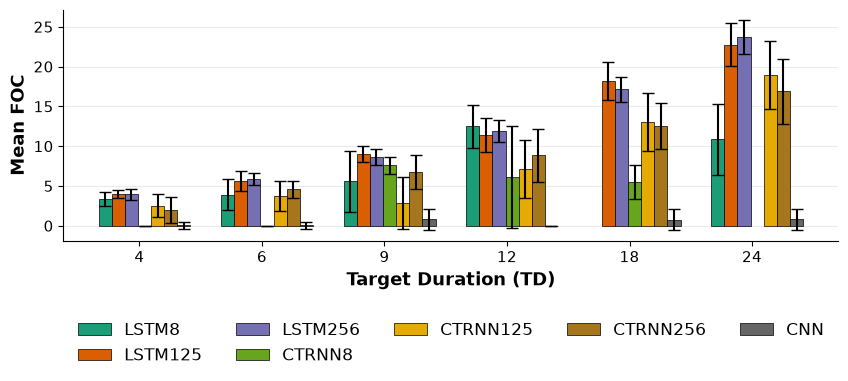

In [24]:
# foc
x = np.arange(len(tds)) * 1.2
width = 0.9 / len(models)

# fig, ax = plt.subplots(figsize=(6,3))
fig, ax = plt.subplots(figsize=(10,3))

cmap = plt.cm.Dark2
colors = [cmap(i) for i in np.linspace(0,1, len(models))]

color_map = dict(zip(models, colors))

for i, model in enumerate(models):
    ax.bar(
        x + i*width - 0.4 + width/2,
        means[model],
        width=width,
        yerr=stds[model],
        capsize=4,
        label=model,
        color=color_map[model],
        edgecolor="black",
        linewidth=0.5,
    )
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.set_xticks(x)
ax.set_xticklabels(tds)
ax.set_xlabel("Target Duration (TD)", fontweight="bold")
ax.set_ylabel("Mean FOC", fontweight="bold")
ax.legend(
    frameon=False,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.6),
    ncols=5
)

# plt.legend(
#     frameon=False,
#     loc="center left",
#     bbox_to_anchor=(1, 0.5)
# )
# plt.savefig("FI_foc.pdf", bbox_inches='tight')
# plt.savefig("FI_foc_supp.pdf", bbox_inches='tight')
plt.show()

/tmp/ipykernel_145/213215376.py:22: RuntimeWarning: Mean of empty slice
  act_seq_count_mean[td] = model_data_filtered.groupby("p_id")["timing_action_flatten"].nunique().values.mean()
/opt/conda/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.13/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.13/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/conda/lib/python3.13/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_145/213215376.py:22: RuntimeWarning: Mean of empty slice
  act_seq_count_mean[td] = model_data_filtered.groupby("p_id

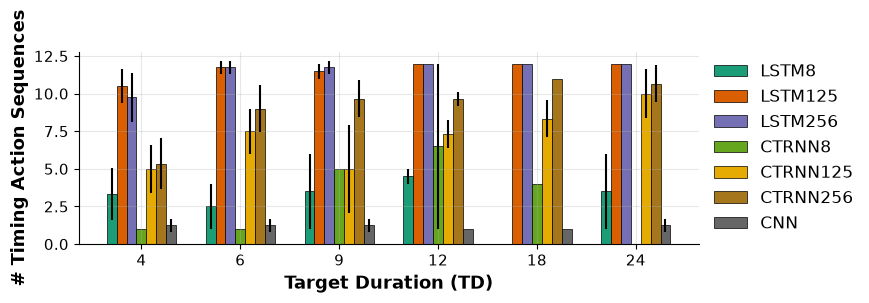

In [25]:
# action seq 
plt.figure(figsize=(8,2.5))

cmap = plt.cm.Dark2
colors = [cmap(i) for i in np.linspace(0,1, len(models))]

TDs = sorted(all_results_df["TD"].unique())

x = np.arange(len(TDs))
width = 0.7 / len(models)


for i, model in enumerate(models):
    model_data = all_results_df[all_results_df["model"]==model]
    act_seq_count_mean = {}
    act_seq_count_sd = {}
    for j, td in enumerate(TDs):
    
        model_data_filtered = model_data[model_data["TD"] == td]
        model_data_filtered["timing_action_flatten"] = model_data_filtered["timing_actions"].apply(lambda x:
                                                                                                   tuple(np.asarray(x).flatten().tolist()))
        act_seq_count_mean[td] = model_data_filtered.groupby("p_id")["timing_action_flatten"].nunique().values.mean()
        act_seq_count_sd[td] = model_data_filtered.groupby("p_id")["timing_action_flatten"].nunique().values.std()
    
    plt.bar(
    x + (i - (len(models) - 1) / 2) * width,
    [act_seq_count_mean[td] for td in TDs],
    width=width,
    yerr=[act_seq_count_sd[td] for td in TDs],
    color=colors[i],
    label=model,
    edgecolor="black",
    linewidth=0.5
)

    # break

# # Styling
# plt.xticks(list(act_seq_count_td.keys()), rotation=45)
plt.xticks(
    x,
    TDs
)
plt.xlabel("Target Duration (TD)", fontweight="bold")
plt.ylabel("# Timing Action Sequences", fontweight="bold")
# plt.title("Sequence Diversity vs LSTM Capacity", fontsize=14)

plt.grid(True, alpha=0.3)
plt.legend(
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)
# plt.tight_layout()

# plt.savefig("FI_num_timing_actions.pdf", bbox_inches='tight')
plt.show()

/tmp/ipykernel_145/297756403.py:75: RuntimeWarning: Mean of empty slice
  act_seq_count_mean[td] = model_data_filtered.groupby("p_id")["timing_action_flatten"].nunique().values.mean()
/opt/conda/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/conda/lib/python3.13/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/lib/python3.13/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/conda/lib/python3.13/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_145/297756403.py:75: RuntimeWarning: Mean of empty slice
  act_seq_count_mean[td] = model_data_filtered.groupby("p_id

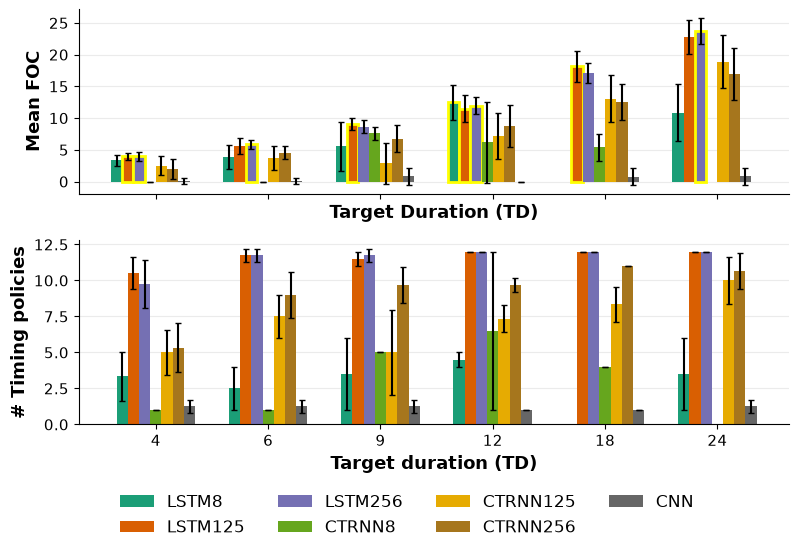

In [31]:
# paper - combine figure
fig, axes = plt.subplots(
    2,1,
    figsize=(8, 5),
    sharex=True
)

cmap = plt.cm.Dark2
colors = [cmap(i) for i in np.linspace(0, 1, len(models))]
color_map = dict(zip(models, colors))

# ============================================================
# FOC
# ============================================================

ax = axes[0]

x = np.arange(len(tds)) 
width = 0.7 / len(models)

for i, model in enumerate(models):


    edgecolors = [
        "#FFFF00" if significance.get((td, model), False) else "none"
        for td in tds
    ]

    
    ax.bar(
        x + i * width - 0.4 + width / 2,
        means[model],
        width=width,
        yerr=stds[model],
        capsize=2,
        label=model,
        color=color_map[model],
        edgecolor=edgecolors,
        linewidth=2,
        linestyle="-"
    )

ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.set_xticks(x)
ax.set_xticklabels(tds)
ax.set_xlabel("Target Duration (TD)", fontweight="bold")
ax.set_ylabel("Mean FOC", fontweight="bold")


# ============================================================
# Timing action sequences
# ============================================================

ax = axes[1]

TDs = sorted(all_results_df["TD"].unique())

x = np.arange(len(TDs))
width = 0.7 / len(models)

for i, model in enumerate(models):

    model_data = all_results_df[
        all_results_df["model"] == model
    ]

    act_seq_count_mean = {}
    act_seq_count_sd = {}

    for td in TDs:
        model_data_filtered = model_data[model_data["TD"] == td]
        model_data_filtered["timing_action_flatten"] = model_data_filtered["timing_actions"].apply(lambda x:
                                                                                                   tuple(np.asarray(x).flatten().tolist()))
        act_seq_count_mean[td] = model_data_filtered.groupby("p_id")["timing_action_flatten"].nunique().values.mean()
        act_seq_count_sd[td] = model_data_filtered.groupby("p_id")["timing_action_flatten"].nunique().values.std()
  

    ax.bar(
        x + (i - (len(models) - 1) / 2) * width,
        [act_seq_count_mean[td] for td in TDs],
        width=width,
        yerr = [act_seq_count_sd[td] for td in TDs],
        color=color_map[model],
        label=model,
        capsize=2,
        # edgecolor="black",
        # linewidth=0.5
    )

ax.set_xticks(x)
ax.set_xticklabels(TDs)
ax.set_xlabel("Target duration (TD)", fontweight="bold")
ax.set_ylabel("# Timing policies", fontweight="bold")
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)


# ============================================================
# One shared legend
# ============================================================

handles, labels = axes[1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    frameon=False,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.12),
    ncols=len(models)-3
)

plt.tight_layout(rect=[0, 0.0, 1, 1])

# plt.savefig(
#     "FI_foc_and_timing_actions.pdf",
#     bbox_inches="tight"
# )

plt.show()

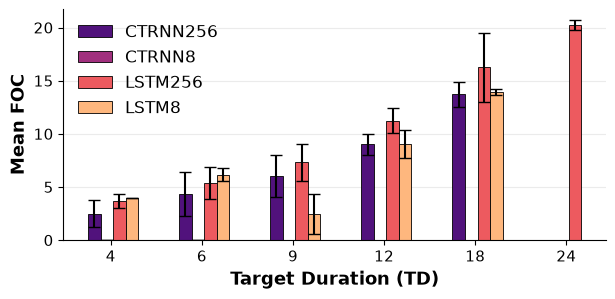

In [81]:
# # supp
# x = np.arange(len(tds)) *1.6
# width = 0.22

# fig, ax = plt.subplots(figsize=(7,3))

# # cmap = plt.cm.plasma
# cmap = plt.cm.magma # sup
# colors = [cmap(i) for i in np.linspace(0.25, 0.85, len(models))]

# color_map = dict(zip(models, colors))

# for i, model in enumerate(models):
#     ax.bar(
#         x + i*width - 0.4 + width/2,
#         means[model],
#         width=width,
#         yerr=stds[model],
#         capsize=4,
#         label=model,
#         color=color_map[model],
#         edgecolor="black",
#         linewidth=0.6,
#     )
# ax.grid(axis="y", alpha=0.25)
# ax.set_axisbelow(True)
# ax.set_xticks(x)
# ax.set_xticklabels(tds)
# ax.set_xlabel("Target Duration (TD)", fontweight="bold")
# ax.set_ylabel("Mean FOC", fontweight="bold")
# ax.legend(frameon=False)
# # plt.savefig("FI_foc.pdf", bbox_inches='tight')
# plt.savefig("FI_foc_supp.pdf", bbox_inches='tight')
# plt.show()

# combine foc with architecture?

In [27]:
colname = "foc"

significance_test_stage1_0_df = all_results_df[["model", "TD", "p_id", colname]].dropna()

# Make categorical variables explicit
significance_test_stage1_0_df["model"] = significance_test_stage1_0_df["model"].astype("category")
significance_test_stage1_0_df["TD"] = significance_test_stage1_0_df["TD"].astype("category")
significance_test_stage1_0_df = significance_test_stage1_0_df.rename(columns={colname:"performance"})
print(significance_test_stage1_0_df.groupby(["model"])["performance"].mean())

for arch in ["LSTM", "CTRNN"]:
    print(arch)
    df = significance_test_stage1_0_df[significance_test_stage1_0_df["model"].str.contains(arch)]

    model = smf.ols(
        # "performance ~ C(memory_size) + C(anchor) + C(memory_size) * C(anchor)",
        "performance ~ C(model) * C(TD)",
        data=df
    ).fit()

    stat, p = shapiro(model.resid)
    print("Shapiro-Wilk:", stat, p)
    print("data size",df.groupby("model")["performance"].describe())

    df["residual"] = model.resid
    res_125 = df[df["model"].str.contains("125")]["residual"]
    res_256 = df[df["model"].str.contains("256")]["residual"]
    
    stat, p = levene(res_125, res_256, center="median")
    
    print(f"Levene: W={stat:.3f}, p={p:.3f}")
       
    # print(sm.stats.anova_lm(model, typ=2))
    anova = sm.stats.anova_lm(model, typ=2)
    # print(model.t_test("C(memory_size)[T.256]"))
    print(anova)
    

# # filtered_avg_bp_jnd_wf_

model
CNN          0.416667
CTRNN125     8.024272
CTRNN256     8.385965
CTRNN8       3.096774
LSTM125     11.836806
LSTM256     11.888889
LSTM8        6.268519
Name: performance, dtype: float64
LSTM
Shapiro-Wilk: 0.8884863019556641 8.276888134742367e-22
data size          count       mean       std  min  25%   50%   75%   max
model                                                          
LSTM125  288.0  11.836806  6.940095  0.0  6.0  10.0  18.0  28.0
LSTM256  288.0  11.888889  6.931332  2.0  6.0  10.0  17.0  30.0
LSTM8    108.0   6.268519  4.458755  0.0  4.0   5.0  10.0  17.0
Levene: W=3.452, p=0.064
                      sum_sq     df             F    PR(>F)
C(model)        2.559079e+05    6.0  1.301484e+04  0.000000
C(TD)           7.964754e-11    5.0  4.860813e-12  0.999998
C(model):C(TD)  5.904245e+04   30.0  6.005506e+02  0.000000
Residual        2.185845e+03  667.0           NaN       NaN
CTRNN
Shapiro-Wilk: 0.9089659539022842 3.161963225043822e-17
data size           count     

/tmp/ipykernel_145/837052357.py:19: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ).fit()
/opt/conda/lib/python3.13/site-packages/statsmodels/base/model.py:1988: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 6, but rank is 2
  res = self.wald_test(
/opt/conda/lib/python3.13/site-packages/statsmodels/base/model.py:1988: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 1
  res = self.wald_test(
/opt/conda/lib/python3.13/site-packages/statsmodels/base/model.py:1988: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 30, but rank is 14
  res = self.wald_test(
/tmp/ipykernel_145/837052357.py:19: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ).fit()
/opt/conda/lib/python3.13/site-packages/statsmodels/base/model.py

# is an architecture closer to TD ?

In [24]:
all_results_df.groupby(["TD","architecture"])["foc"].describe()

count       mean       std  min    25%   50%    75%   max
TD architecture                                                           
4  CNN            48.0   0.062500  0.433013  0.0   0.00   0.0   0.00   3.0
   CTRNN         102.0   1.735294  1.658620  0.0   0.00   3.0   3.00   5.0
   LSTM          132.0   3.810606  0.732376  2.0   4.00   4.0   4.00   5.0
6  CNN            48.0   0.062500  0.433013  0.0   0.00   0.0   0.00   3.0
   CTRNN          96.0   3.208333  2.238029  0.0   0.00   4.0   5.00   6.0
   LSTM          120.0   5.391667  1.439513  0.0   5.00   6.0   6.00   8.0
9  CNN            48.0   0.812500  1.347279  0.0   0.00   0.0   3.00   3.0
   CTRNN          84.0   5.214286  3.274845  0.0   3.00   6.0   8.00  10.0
   LSTM          113.0   8.265487  2.112960  0.0   8.00   9.0  10.00  11.0
12 CNN            48.0   0.000000  0.000000  0.0   0.00   0.0   0.00   0.0
   CTRNN          96.0   7.531250  4.460241  0.0   6.00   9.0  11.00  14.0
   LSTM          102.0  11.794118  2.074543  0.0  11.00  12.0  12.00  17.0
18 CNN            48.0   0.750000  1.312785  0.0   0.00   0.0   0.75   3.0
   CTRNN          77.0  11.909091  3.934269  0.0   9.00  13.0  15.00  17.0
   LSTM           84.0  17.738095  2.190445  7.0  16.75  18.0  19.00  23.0
24 CNN            48.0   0.812500  1.347279  0.0   0.00   0.0   3.00   3.0
   CTRNN          72.0  17.916667  4.258380  0.0  17.00  19.0  19.00  27.0
   LSTM           97.0  21.597938  5.102409  4.0  21.00  23.0  24.00  30.0

In [28]:
# all significantly different from td 
for td in all_results_df["TD"].unique():
    for arch in all_results_df["architecture"].unique():
        significance_test_df = all_results_df[(all_results_df["TD"]==td) & (all_results_df["architecture"]==arch)]

        # stat, p = shapiro(model.resid)
        # print("Shapiro-Wilk:", stat, p)
        print("data size",len(significance_test_df))
        t, p = ttest_1samp(significance_test_df["foc"], popmean=td, nan_policy="omit")
        
        # stat, p = levene(lstm, ctrnn, center="median")  
        # print("equal variance",stat,p)

        print(td, arch, t,p)


data size 102
4 CTRNN -13.790025896521682 5.864246703008835e-25
data size 132
4 LSTM -2.9711097693379713 0.0035311757314910484
data size 48
4 CNN -63.00000000000001 4.690080008874175e-47
data size 96
6 CTRNN -12.221754311834456 3.3536072427411235e-21
data size 120
6 LSTM -4.629312725633947 9.429382156570556e-06
data size 48
6 CNN -95.00000000000001 2.2539339479838392e-55
data size 84
9 CTRNN -10.594895256145085 4.3615274716694905e-17
data size 113
9 LSTM -3.310860675589481 0.0012521507099427693
data size 48
9 CNN -42.1031438882505 5.668591041228514e-39
data size 96
12 CTRNN -9.816650918198343 4.072130277949316e-16
data size 114
12 LSTM -0.895888844907615 0.372216647331671
data size 48
12 CNN -inf 0.0
data size 77
18 CTRNN -13.585120053295155 5.005358257527293e-22
data size 96
18 LSTM -1.6024824364228958 0.11236891735558423
data size 48
18 CNN -91.03662266729071 1.652665979052748e-54
data size 72
24 CTRNN -12.1216968276138 5.842221760447914e-19
data size 109
24 LSTM -4.78370070559845 5.

# is model closer to TD ?

In [20]:
all_results_df.groupby(["TD","model"])["foc"].describe()

count       mean       std   min    25%   50%    75%   max
TD model                                                               
4  CNN        48.0   0.062500  0.433013   0.0   0.00   0.0   0.00   3.0
   CTRNN125   42.0   2.523810  1.435408   0.0   2.25   3.0   3.00   5.0
   CTRNN256   36.0   1.972222  1.629831   0.0   0.00   3.0   3.00   4.0
   CTRNN8     24.0   0.000000  0.000000   0.0   0.00   0.0   0.00   0.0
   LSTM125    48.0   3.979167  0.525502   3.0   4.00   4.0   4.00   5.0
   LSTM256    48.0   3.958333  0.682870   2.0   4.00   4.0   4.00   5.0
   LSTM8      36.0   3.388889  0.871051   2.0   2.75   4.0   4.00   4.0
6  CNN        48.0   0.062500  0.433013   0.0   0.00   0.0   0.00   3.0
   CTRNN125   24.0   3.708333  1.876147   0.0   3.00   4.0   5.00   6.0
   CTRNN256   48.0   4.562500  1.070022   0.0   4.00   5.0   5.00   6.0
   CTRNN8     24.0   0.000000  0.000000   0.0   0.00   0.0   0.00   0.0
   LSTM125    48.0   5.625000  1.231242   0.0   5.00   6.0   6.00   8.0
   LSTM256    48.0   5.895833  0.721688   3.0   6.00   6.0   6.00   7.0
   LSTM8      24.0   3.916667  1.909169   0.0   3.00   5.0   5.00   5.0
9  CNN        48.0   0.812500  1.347279   0.0   0.00   0.0   3.00   3.0
   CTRNN125   36.0   2.861111  3.208496   0.0   0.00   0.0   6.00   8.0
   CTRNN256   36.0   6.777778  2.152887   0.0   6.00   7.0   8.00  10.0
   CTRNN8     12.0   7.583333  1.083625   6.0   7.00   8.0   8.00  10.0
   LSTM125    48.0   9.020833  0.956269   6.0   8.75   9.0  10.00  11.0
   LSTM256    48.0   8.666667  0.974861   6.0   8.00   9.0   9.00  11.0
   LSTM8      17.0   5.588235  3.857765   0.0   2.00   5.0  10.00  10.0
12 CNN        48.0   0.000000  0.000000   0.0   0.00   0.0   0.00   0.0
   CTRNN125   36.0   7.138889  3.610720   0.0   7.00   8.0  10.00  11.0
   CTRNN256   36.0   8.833333  3.307999   0.0   7.00  10.0  11.00  12.0
   CTRNN8     24.0   6.166667  6.390663   0.0   0.00   4.5  13.00  14.0
   LSTM125    48.0  11.458333  2.133405   0.0  11.00  12.0  12.00  16.0
   LSTM256    48.0  11.958333  1.383156   8.0  11.00  12.0  13.00  17.0
   LSTM8      18.0  12.500000  2.727852   9.0  11.00  11.0  16.00  17.0
18 CNN        48.0   0.750000  1.312785   0.0   0.00   0.0   0.75   3.0
   CTRNN125   32.0  13.031250  3.702522   0.0  12.00  14.0  15.25  17.0
   CTRNN256   36.0  12.527778  2.853430   7.0  10.00  13.0  15.00  16.0
   CTRNN8      9.0   5.444444  2.127858   0.0   6.00   6.0   6.00   7.0
   LSTM125    48.0  18.187500  2.429046   7.0  17.00  18.0  20.00  23.0
   LSTM256    48.0  17.125000  1.565927  14.0  16.00  17.0  18.00  20.0
24 CNN        48.0   0.812500  1.347279   0.0   0.00   0.0   3.00   3.0
   CTRNN125   36.0  18.916667  4.245165   0.0  17.00  19.0  20.00  27.0
   CTRNN256   36.0  16.916667  4.087437   0.0  16.75  18.0  19.00  22.0
   LSTM125    48.0  22.750000  2.724983  12.0  21.00  23.0  24.00  28.0
   LSTM256    48.0  23.729167  2.090908  19.0  23.00  23.5  25.00  30.0
   LSTM8      13.0  10.846154  4.487875   4.0   7.00   9.0  15.00  16.0

In [29]:
# all significantly different from td 
significance ={}
for td in all_results_df["TD"].unique():
    for model in models:
        significance_test_df = all_results_df[(all_results_df["TD"]==td) & (all_results_df["model"]==model)]

        # stat, p = shapiro(model.resid)
        # print("Shapiro-Wilk:", stat, p)
        print("data size",len(significance_test_df))
        t, p = ttest_1samp(significance_test_df["foc"], popmean=td, nan_policy="omit")
        
        # stat, p = levene(lstm, ctrnn, center="median")  
        # print("equal variance",stat,p)
        significance[(td, model)] = p >= 0.05
        print(td, model, np.mean(significance_test_df["foc"]), np.std(significance_test_df["foc"]), t,p)


data size 36
4 LSTM8 3.388888888888889 0.8588680463189057 -4.209473277260058 0.00016960160722877517
data size 48
4 LSTM125 3.9791666666666665 0.519999332264529 -0.27466600175497746 0.7847766098628166
data size 48
4 LSTM256 3.9583333333333335 0.6757197808427855 -0.422737772542979 0.67441449874906
data size 24
4 CTRNN8 0.0 0.0 -inf 0.0
data size 42
4 CTRNN125 2.5238095238095237 1.4182164392224224 -6.664871986919878 4.909583390261923e-08
data size 36
4 CTRNN256 1.9722222222222223 1.607035073791192 -7.464986490573962 9.69227619035532e-09
data size 48
4 CNN 0.0625 0.42847841252506524 -63.00000000000001 4.690080008874175e-47
data size 24
6 LSTM8 3.9166666666666665 1.8689717910004842 -5.34588896508689 1.9859844752519106e-05
data size 48
6 LSTM125 5.625 1.2183492931011204 -2.110125962815341 0.040198519872892066
data size 48
6 LSTM256 5.895833333333333 0.7141306875417753 -1.0000000000000029 0.32243134001596563
data size 24
6 CTRNN8 0.0 0.0 -inf 0.0
data size 24
6 CTRNN125 3.7083333333333335 1.8

/tmp/ipykernel_145/1864291307.py:10: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t, p = ttest_1samp(significance_test_df["foc"], popmean=td, nan_policy="omit")


In [30]:
# supp data for significance tets

results = []

for td in all_results_df["TD"].unique():
    for model in models:
        df = all_results_df[
            (all_results_df["TD"] == td) &
            (all_results_df["model"] == model)
        ]

        foc = df["foc"].dropna()

        t, p = ttest_1samp(foc, popmean=td)

        results.append({
            "TD":td,
            "Model": model,
            "N": len(foc),
            "M": np.mean(foc),
            "SD": np.std(foc, ddof=1),
            "t": t,
            "p": p
        })

results_df = pd.DataFrame(results)

# Format numbers
latex_df = results_df.copy()
latex_df["M"] = latex_df["M"].map(lambda x: f"{x:.2f}")
latex_df["SD"] = latex_df["SD"].map(lambda x: f"{x:.2f}")
latex_df["t"] = latex_df["t"].map(lambda x: f"{x:.2f}")
latex_df["p"] = latex_df["p"].map(lambda x: f"{x:.3f}")

# Generate LaTeX
latex_table = latex_df.to_latex(
    index=False,
    escape=False,
    column_format="lrrrrr"
)

print(latex_table)

\begin{tabular}{lrrrrr}
\toprule
TD & Model & N & M & SD & t & p \\
\midrule
4 & LSTM8 & 36 & 3.39 & 0.87 & -4.21 & 0.000 \\
4 & LSTM125 & 48 & 3.98 & 0.53 & -0.27 & 0.785 \\
4 & LSTM256 & 48 & 3.96 & 0.68 & -0.42 & 0.674 \\
4 & CTRNN8 & 24 & 0.00 & 0.00 & -inf & 0.000 \\
4 & CTRNN125 & 42 & 2.52 & 1.44 & -6.66 & 0.000 \\
4 & CTRNN256 & 36 & 1.97 & 1.63 & -7.46 & 0.000 \\
4 & CNN & 48 & 0.06 & 0.43 & -63.00 & 0.000 \\
6 & LSTM8 & 24 & 3.92 & 1.91 & -5.35 & 0.000 \\
6 & LSTM125 & 48 & 5.62 & 1.23 & -2.11 & 0.040 \\
6 & LSTM256 & 48 & 5.90 & 0.72 & -1.00 & 0.322 \\
6 & CTRNN8 & 24 & 0.00 & 0.00 & -inf & 0.000 \\
6 & CTRNN125 & 24 & 3.71 & 1.88 & -5.98 & 0.000 \\
6 & CTRNN256 & 48 & 4.56 & 1.07 & -9.31 & 0.000 \\
6 & CNN & 48 & 0.06 & 0.43 & -95.00 & 0.000 \\
9 & LSTM8 & 17 & 5.59 & 3.86 & -3.65 & 0.002 \\
9 & LSTM125 & 48 & 9.02 & 0.96 & 0.15 & 0.881 \\
9 & LSTM256 & 48 & 8.67 & 0.97 & -2.37 & 0.022 \\
9 & CTRNN8 & 12 & 7.58 & 1.08 & -4.53 & 0.001 \\
9 & CTRNN125 & 36 & 2.86 & 3.21 & -11

/tmp/ipykernel_145/1020732430.py:14: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t, p = ttest_1samp(foc, popmean=td)


# human-like timing

In [32]:
list_of_dfs = [foc_data_df_lstm8, foc_data_df_lstm125, foc_data_df_lstm256, foc_data_df_ctrnn8, 
               foc_data_df_ctrnn125, foc_data_df_ctrnn256]
all_results_df = pd.concat(list_of_dfs, ignore_index=True)

# all_results_df = all_results_df[all_results_df["TD"]!=24]

stats = all_results_df.groupby(["TD", "model"])["foc"].agg(["mean", "std"]).reset_index()
means = stats.pivot(index="TD", columns="model", values="mean")
stds  = stats.pivot(index="TD", columns="model", values="std")

tds = means.index.tolist()
# models = means.columns.tolist()
models = [
    "LSTM8",
    "LSTM125",
    "LSTM256",
    "CTRNN8",
    "CTRNN125",
    "CTRNN256",

]

all_results_df["architecture"] = all_results_df["model"].str.extract(r"^([A-Za-z]+)")
all_results_df["memory_size"] = all_results_df["model"].str.extract(r"(\d+)$")
all_results_df

,TD,p_id,seed,foc,model,timing_actions,architecture,memory_size
0,4,900000_1,0,4,LSTM8,"[5, 4, 4, 5]",LSTM,8
1,4,900000_1,1,4,LSTM8,"[5, 4, 4, 5]",LSTM,8
2,4,900000_1,2,4,LSTM8,"[5, 4, 4, 5]",LSTM,8
3,4,900000_1,3,4,LSTM8,"[5, 4, 4, 5]",LSTM,8
4,4,900000_1,4,4,LSTM8,"[5, 4, 4, 5]",LSTM,8
...,...,...,...,...,...,...,...,...
1206,24,900000_3,7,20,CTRNN256,"[1, 1, 1, 1, 1, 1, 1, 1, 5, 3, 5, 4, 4, 5, 2, ...",CTRNN,256
1207,24,900000_3,8,18,CTRNN256,"[1, 1, 5, 5, 1, 1, 1, 5, 5, 5, 3, 5, 4, 4, 5, ...",CTRNN,256
1208,24,900000_3,9,18,CTRNN256,"[1, 1, 1, 1, 1, 1, 1, 5, 3, 5, 4, 5, 5, 4, 5, ...",CTRNN,256
1209,24,900000_3,10,18,CTRNN256,"[1, 1, 1, 1, 1, 1, 1, 5, 5, 3, 5, 4, 5, 4, 5, ...",CTRNN,256


In [33]:
# linearly varying means with target durations?
from sklearn.linear_model import LinearRegression


# models = means.columns.tolist()
for m in models:
    
    means_m = means[m].dropna()
    tds = means_m.index.tolist()
    
        
    x = np.array(tds).reshape(-1,1)  # target durations
    y = np.array(means_m.reset_index(drop=True))
    
    model = LinearRegression(fit_intercept=True)
    model.fit(x, y)
    CV_fit = model.coef_[0]
    R2 = model.score(x, y)
    
    # print("Fitted CV:", CV_fit)
    print(f"{m} && {np.round(R2,2)}", len(x))
    # break


LSTM8 && 0.57 5
LSTM125 && 1.0 6
LSTM256 && 1.0 6
CTRNN8 && 0.44 5
CTRNN125 && 0.95 6
CTRNN256 && 0.99 6


In [34]:
# linearly varying std. with means

# models = stds.columns.tolist()
for m in models:
    
    stds_m = stds[m].dropna().reset_index(drop=True)
    means_m = means[m].dropna().reset_index(drop=True)
    
        
    x = np.array(means_m).reshape(-1,1)  
    y = np.array(stds_m)
    
    model = LinearRegression(fit_intercept=True)
    model.fit(x, y)
    CV_fit = model.coef_[0]
    R2 = model.score(x, y)
    slope = model.coef_[0]  
    
    # print("Fitted CV:", CV_fit)
    print(f"{m} && R2: {R2:.2f}",len(x))

LSTM8 && R2: 0.35 5
LSTM125 && R2: 0.85 6
LSTM256 && R2: 0.98 6
CTRNN8 && R2: 0.35 5
CTRNN125 && R2: 0.62 6
CTRNN256 && R2: 0.79 6


In [44]:
for m in models:
    cv = (stds[m] / means[m]).dropna()
    print(m, cv)

CTRNN125 TD
9     1.139479
12    2.340341
18    0.270664
24    0.045584
Name: CTRNN125, dtype: float64
CTRNN256 TD
4     0.497265
6     0.485397
9     0.325516
12    0.105940
18    0.087324
Name: CTRNN256, dtype: float64
LSTM125 TD
4     0.417477
6     0.412976
9     0.329017
12    0.266551
18    0.107767
24    0.240479
Name: LSTM125, dtype: float64
LSTM256 TD
4     0.177638
6     0.273280
9     0.236759
12    0.102361
18    0.201461
24    0.022334
Name: LSTM256, dtype: float64
LSTM8 TD
4     0.000000
6     0.093624
9     0.753175
12    0.144371
18    0.020743
Name: LSTM8, dtype: float64


In [45]:

cv = (stds / means)
cv = cv[[ "CTRNN125","LSTM125",]]
cv.index.name = "TD"

print(cv.to_latex(float_format="%.2f"))


\begin{tabular}{lrr}
\toprule
model & CTRNN125 & LSTM125 \\
TD &  &  \\
\midrule
4 & NaN & 0.42 \\
6 & NaN & 0.41 \\
9 & 1.14 & 0.33 \\
12 & 2.34 & 0.27 \\
18 & 0.27 & 0.11 \\
24 & 0.05 & 0.24 \\
\bottomrule
\end{tabular}



In [31]:
models

['LSTM8', 'LSTM125', 'LSTM256', 'CTRNN8', 'CTRNN125', 'CTRNN256']

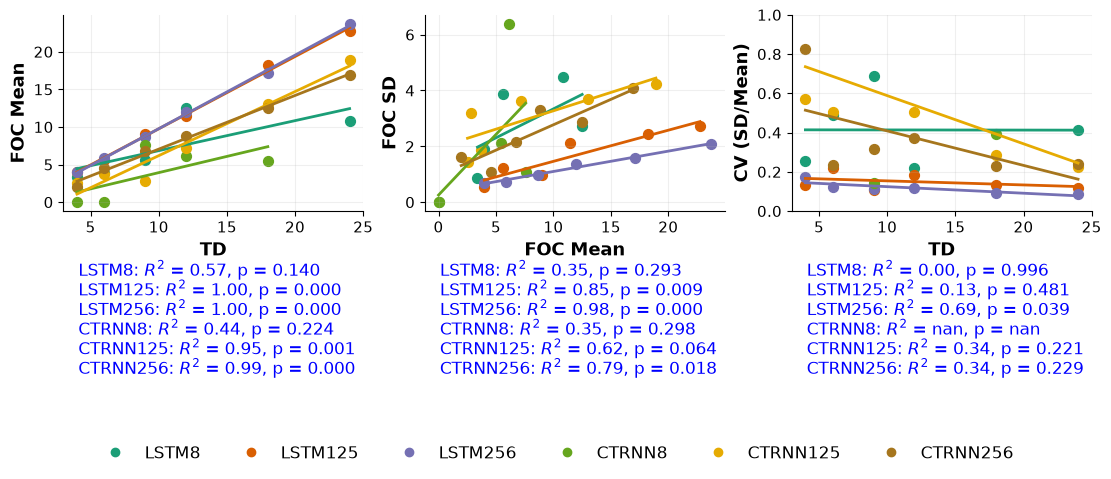

In [35]:
from scipy.stats import linregress

color_map_filtered = {m:c for m,c in color_map.items() if m in models}



fig, axes = plt.subplots(1, 3, figsize=(11, 3.5), constrained_layout=True)

ax_mean, ax_std, ax_cv = axes

mean_stats = []
std_stats = []
cv_stats = []

for m in models:
    color = color_map_filtered[m]

    # =========================
    # Mean vs TD
    # =========================

    means_m = means[m].dropna()

    tds = means_m.index.to_numpy(dtype=float)
    y = means_m.to_numpy()

    result = linregress(tds, y)

    slope = result.slope
    intercept = result.intercept
    R2 = result.rvalue**2
    p = result.pvalue

    mean_stats.append((m, R2, p, color))

    x_line = np.linspace(tds.min(), tds.max(), 100)
    y_line = intercept + slope * x_line

    ax_mean.scatter(
        tds, y,
        color=color,
        s=50
    )

    ax_mean.plot(
        x_line, y_line,
        color=color,
        linewidth=2
    )

    # =========================
    # SD vs Mean
    # =========================

    stds_m = stds[m].dropna()
    means_m = means[m].dropna()

    x = np.array(means_m) 
    y = np.array(stds_m)

    # tds_std = stds_m.index.to_numpy(dtype=float)
    # y_std = stds_m.to_numpy()

    result_std = linregress(x, y)

    slope_std = result_std.slope
    intercept_std = result_std.intercept
    R2_std = result_std.rvalue**2
    p_std = result_std.pvalue

    std_stats.append((m, R2_std, p_std, color))

    x_line_std = np.linspace(
        x.min(),
        x.max(),
        100
    )

    y_line_std = intercept_std + slope_std * x_line_std

    ax_std.scatter(
        x, y,
        color=color,
        s=50
    )

    ax_std.plot(
        x_line_std, y_line_std,
        color=color,
        linewidth=2
    )

    # =========================
    # CV vs TD
    # =========================

    means_m = means[m].dropna()
    stds_m = stds[m].dropna()
    cv = stds_m / means_m

    tds = means_m.index.to_numpy(dtype=float)
    y = cv.to_numpy()

    result = linregress(tds, y)

    slope = result.slope
    intercept = result.intercept
    R2 = result.rvalue**2
    p = result.pvalue

    cv_stats.append((m, slope, R2, p, color))

    x_line = np.linspace(tds.min(), tds.max(), 100)
    y_line = intercept + slope * x_line

    ax_cv.scatter(
        tds, y,
        color=color,
        s=50
    )

    ax_cv.plot(
        x_line, y_line,
        color=color,
        linewidth=2
    )
    ax_cv.set_ylim(0,1)


# =========================
# R² + p-value boxes
# =========================

for i, (m, r2, p, color) in enumerate(mean_stats):

    ax_mean.text(
        0.05,
        -0.25 - i * 0.1,
        f"{m}: $R^2$ = {r2:.2f}, p = {p:.3f}",
        transform=ax_mean.transAxes,
        verticalalignment="top",
        color="blue",
        # fontsize=8,
        # bbox=dict(
        #     boxstyle="round,pad=0.25",
        #     facecolor="white",
        #     alpha=0.8
        # )
    )


for i, (m, r2, p, color) in enumerate(std_stats):

    ax_std.text(
        0.05,
        -0.25 - i * 0.1,
        f"{m}: $R^2$ = {r2:.2f}, p = {p:.3f}",
        transform=ax_std.transAxes,
        verticalalignment="top",
        color="blue",
        # fontsize=8,
        # bbox=dict(
        #     boxstyle="round,pad=0.25",
        #     facecolor="white",
        #     alpha=0.8
        # )
    )

for i, (m, s, r2, p, color) in enumerate(cv_stats):

    ax_cv.text(
        0.05,
        -0.25 - i * 0.1,
        f"{m}: $R^2$ = {r2:.2f}, p = {p:.3f}",
        transform=ax_cv.transAxes,
        verticalalignment="top",
        color="blue",
       
        # fontsize=8,
        # bbox=dict(
        #     boxstyle="round,pad=0.25",
        #     facecolor="white",
        #     alpha=0.8
        # )
    )
# =========================
# Formatting
# =========================

ax_mean.set_xlabel("TD", fontweight="bold")
ax_mean.set_ylabel("FOC Mean",fontweight="bold")
# ax_mean.set_title("Mean produced duration vs target duration")

ax_std.set_xlabel("FOC Mean",fontweight="bold")
ax_std.set_ylabel("FOC SD",fontweight="bold")
# ax_std.set_title("Standard deviation vs target duration")
ax_cv.set_ylabel("CV (SD/Mean)",fontweight="bold")
ax_cv.set_xlabel("TD",fontweight="bold")


ax_mean.grid(alpha=0.2)
ax_std.grid(alpha=0.2)
ax_cv.grid(alpha=0.2)

# Legend
handles = [
    plt.Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        color=color_map_filtered[m],
        label=m
    )
    for m in  models
]

fig.legend(
    handles=handles,
    # title="Model",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.35),
    ncols=len(models),
    frameon=False,
)

# fig.legend(
#     handles,
#     labels,
#     frameon=False,
#     loc="lower center",
#     bbox_to_anchor=(0.5, -0.12),
#     ncols=len(models)-3
# )

plt.savefig(
    "FI_scalar_timing.pdf",
    bbox_inches="tight"
)
# plt.tight_layout()
plt.show()

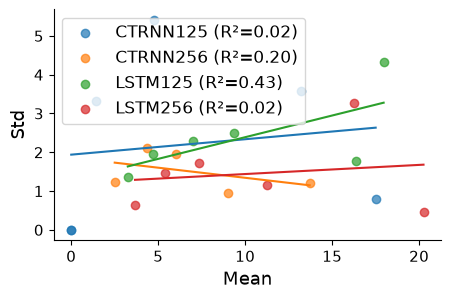

In [260]:
# plot scalalr property
models = stds.columns.tolist()

fig, ax = plt.subplots(figsize=(5,3))

colors = plt.cm.tab10.colors

for i, m in enumerate(models):

    stds_m = stds[m].dropna().reset_index(drop=True)
    means_m = means[m].dropna().reset_index(drop=True)

    x = np.array(means_m).reshape(-1, 1)
    y = np.array(stds_m)

    model = LinearRegression(fit_intercept=True)
    model.fit(x, y)

    y_fit = model.predict(x)
    r2 = model.score(x, y)

    # scatter
    ax.scatter(means_m, stds_m, color=colors[i % len(colors)], alpha=0.7, label=f"{m} (R²={r2:.2f})")

    # regression line
    x_line = np.linspace(means_m.min(), means_m.max(), 100).reshape(-1, 1)
    y_line = model.predict(x_line)

    ax.plot(x_line, y_line, color=colors[i % len(colors)])

ax.set_xlabel("Mean")
ax.set_ylabel("Std")
# ax.legend(ncols=len(models))
ax.legend()
plt.show()


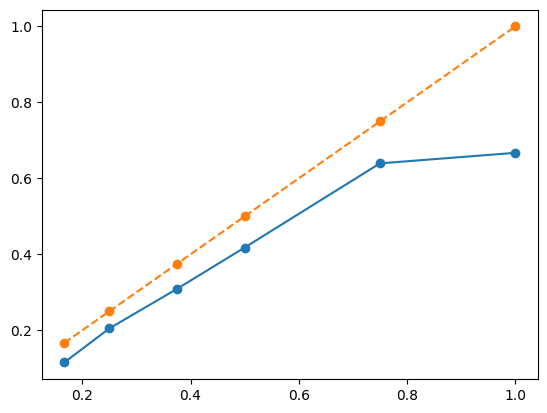

In [77]:
plt.plot([td/24 for td in target_durations], [m/24 for m in means["lstm"]], "-o")
plt.plot([td/24 for td in target_durations], [td/24 for td in target_durations], "--o")

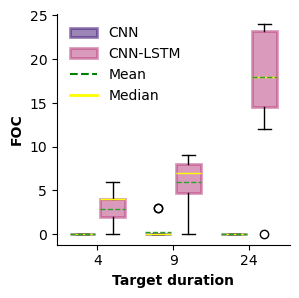

In [94]:
# Data in order of target duration
data = [
    cnn_foc_4, lstm_foc_4,
    cnn_foc_9, lstm_foc_9,
    cnn_foc_24, lstm_foc_24
]

# Positions on x-axis
positions = [1, 1.6, 2.5, 3.1, 4, 4.6]  # leave space between target durations

# Colors for models
# colors = ['skyblue', 'orange'] * 3  # alternating CNN/LSTM
cmap = plt.get_cmap("magma")
colors = [cmap(0.2),cmap(0.5)] * 3
fig, ax = plt.subplots(figsize=(3,3))

bp = ax.boxplot(data, positions=positions, patch_artist=True, showmeans=True, meanline=True)

# Color boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
    patch.set_edgecolor(color)
    patch.set_linewidth(2)

# Set different median colors for CNN and LSTM
cnn_median_color = "yellow"
lstm_median_color = "yellow"

for i, median in enumerate(bp['medians']):
    if i % 2 == 0:   # CNN
        median.set_color(cnn_median_color)
    else:            # LSTM
        median.set_color(lstm_median_color)
    median.set_linewidth(1)

# X-ticks centered between CNN and LSTM
ax.set_xticks([1.3, 2.8, 4.3])
ax.set_xticklabels([4, 9, 24])  # target durations

mean_handle = Line2D([0], [0], color='green',
                     linestyle='--', markersize=6, label='Mean')
median_handle = Line2D([0], [0], color='yellow',
                       linewidth=2, label='Median')

ax.legend(
    handles=[bp["boxes"][0], bp["boxes"][1], mean_handle, median_handle],
    labels=["CNN", "CNN-LSTM", "Mean", "Median"],
    loc="upper left",
    frameon=False,
)
ax.set_xlabel("Target duration", fontweight="bold")
ax.set_ylabel("FOC", fontweight="bold")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.legend([bp["boxes"][0], bp["boxes"][1]], ["CNN", "LSTM"], loc='upper left')

plt.show()
fig.savefig("ICML2026/figures/foc_distribution.pdf", dpi=300, bbox_inches="tight")

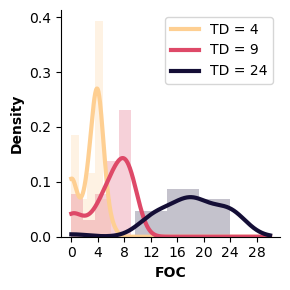

In [93]:
plt.figure(figsize=(3,3))

bins = 5
x_grid = np.linspace(0, 30, 500)  # adjust range if needed

lstm_data = {
    "TD = 4": (lstm_foc_4, cmap(0.9)),
    "TD = 9": (lstm_foc_9, cmap(0.6)),
    # "T=9 no-nav": ([s_foc[i][0] for s_foc in lstm_foc_history["9_nonav"].values() for i in s_foc.keys()], "tab:red"),
    "TD = 24": (lstm_foc_24, cmap(0.1)),
}

for label, (data, color) in lstm_data.items():
    # Histogram (normalized)
    plt.hist(
        data,
        bins=bins,
        density=True,
        alpha=0.25,
        color=color
    )
    # bin_width = (max(data) - min(data)) / bins
    # Smooth curve (KDE)
    kde = gaussian_kde(data)
    plt.plot(
        x_grid,
        kde(x_grid),
        color=color,
        linewidth=3,
        label=label
    )

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel("FOC", fontweight="bold")
plt.ylabel("Density", fontweight="bold")
plt.xticks(range(0,31,4))
plt.legend()
plt.tight_layout()
plt.savefig("ICML2026/figures/scalar_property.pdf", dpi=300, bbox_inches="tight")
plt.show()
